# Now lets try with PlanetScope data!

In [ ]:
!pip install earthengine-api

In [ ]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.5 MB/s eta 0:00:00


Do not foreget to install earth engine, geemap and other packages!

In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [ ]:
We need to link out GEE account to the notebook.

In [ ]:
ee.Authenticate()

And we need to call our project!

In [ ]:
ee.Initialize(project='pangeos-forest-training')

Now, lets load our data, here again we have our tree points.

In [ ]:
tree_points = ee.FeatureCollection("projects/ee-kaplangorde/assets/wytham_wgs84")

In [ ]:
import ee

# Authenticate (only required once)
ee.Authenticate()

# Initialize the Earth Engine API
ee.Initialize()




And lets see them!

In [ ]:
# Let's visualize it on a map to check if our coordinates are correct
#Thanks to the geemap package we have installed earlier we will be able to map our data.

Map = geemap.Map()
Map.centerObject(tree_points, zoom=17) # center map automatically by layer
Map.addLayer(tree_points, {}, "Trees")
Map


Map(center=[51.77621712737697, -1.3372576632013358], controls=(WidgetControl(options=['position', 'transparent…

Now lets see inside of them!

In [ ]:
# Get list of unique 'common_nam' values
names = tree_points.aggregate_array('common_nam').distinct().getInfo()

# Loop through each class name and count how many trees are in it
for name in names:
    count = tree_points.filter(ee.Filter.eq('common_nam', name)).size().getInfo()
    print(f"{name}: {count} trees")


Common hawthorn: 197 trees
Common dogwood: 1 trees
Field maple: 65 trees
Silver birch: 3 trees
European beech: 5 trees
Elder: 33 trees
Sycamore: 2358 trees
European larch: 3 trees
European ash: 927 trees
Common hazel: 576 trees
English oak: 103 trees


We have very unballanced data set! We need to leave back the classes with less than 50 trees.

In [ ]:
# Step 1: Get list of unique class names
names = tree_points.aggregate_array('common_nam').distinct().getInfo()

# Step 2: Keep only names with >= 50 samples
valid_names = []
for name in names:
    count = tree_points.filter(ee.Filter.eq('common_nam', name)).size().getInfo()
    if count >= 50:
        valid_names.append(name)

print("Classes with at least 50 trees:", valid_names)

# Step 3: Filter tree_points to only include valid classes
filtered_tree_points = tree_points.filter(ee.Filter.inList('common_nam', valid_names))

print("✅ Classes kept (≥ 50 trees):")
for name in valid_names:
    print(f" - {name}")

print(f"\nTotal classes retained: {len(valid_names)}")


Classes with at least 50 trees: ['Common hawthorn', 'Field maple', 'Sycamore', 'European ash', 'Common hazel', 'English oak']
✅ Classes kept (≥ 50 trees):
 - Common hawthorn
 - Field maple
 - Sycamore
 - European ash
 - Common hazel
 - English oak

Total classes retained: 6


Lest put some color to our map! Cuz everything is better in color!

In [ ]:
import random

# Helper function to get a random color
def random_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

# Create map
Map = geemap.Map()
Map.centerObject(filtered_tree_points, zoom=17)

# Get unique class names
class_names = filtered_tree_points.aggregate_array('common_nam').distinct().getInfo()

# Loop and add each class with a color
for name in class_names:
    subset = filtered_tree_points.filter(ee.Filter.eq('common_nam', name))
    color = random_color()
    Map.addLayer(subset, {'color': color}, name)

Map


Map(center=[51.776217398771294, -1.3372612108090889], controls=(WidgetControl(options=['position', 'transparen…

Now, this is the time call our PlanetScope data. The data are stored in my GEE assests, and I they are available for use using the snipents bellow.

In [ ]:
# Band names for 8-band SR PlanetScope images (SuperDove)
bands = ['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8']

# Map image paths to their acquisition dates
images = {
    '2022-04-15': "projects/ee-kaplangorde/assets/wytham_ps/20220415_104236_95_2489_3B_AnalyticMS_SR_8b_clip",
    '2022-05-19': "projects/ee-kaplangorde/assets/wytham_ps/20220519_104143_67_248f_3B_AnalyticMS_SR_8b_clip",
    '2022-06-15': "projects/ee-kaplangorde/assets/wytham_ps/20220615_104134_65_248b_3B_AnalyticMS_SR_8b_clip",
    '2022-07-16': "projects/ee-kaplangorde/assets/wytham_ps/20220716_104517_59_2479_3B_AnalyticMS_SR_8b_clip",
    '2022-08-19': "projects/ee-kaplangorde/assets/wytham_ps/20220819_105313_71_2254_3B_AnalyticMS_SR_8b_clip",
    '2022-09-16': "projects/ee-kaplangorde/assets/wytham_ps/20220916_104528_64_2478_3B_AnalyticMS_SR_8b_clip",
    '2022-10-16': "projects/ee-kaplangorde/assets/wytham_ps/20221016_100915_77_2420_3B_AnalyticMS_SR_8b_clip",
    '2022-11-23': "projects/ee-kaplangorde/assets/wytham_ps/20221123_105018_42_227a_3B_AnalyticMS_SR_8b_clip"
}

# Define seasons manually
seasons = {
    'Spring': ['2022-04-15', '2022-05-19'],
    'Summer': ['2022-06-15', '2022-07-16', '2022-08-19'],
    'Autumn': ['2022-09-16', '2022-10-16', '2022-11-23']
}

In [ ]:
results = {}

for season, dates in seasons.items():
    dfs = []
    for date in dates:
        img = ee.Image(images[date])

        sampled = img.select(bands).sampleRegions(
            collection=tree_points,
            properties=['common_nam'],
            scale=3,
            geometries=False
        )

        # Convert EE FeatureCollection to client-side pandas DataFrame
        features = sampled.getInfo()['features']
        df = pd.DataFrame([{**f['properties']} for f in features])
        df['date'] = date
        dfs.append(df)

    # Concatenate all data for this season
    results[season] = pd.concat(dfs, ignore_index=True)


Here lets see some seasonal spectral signatures!

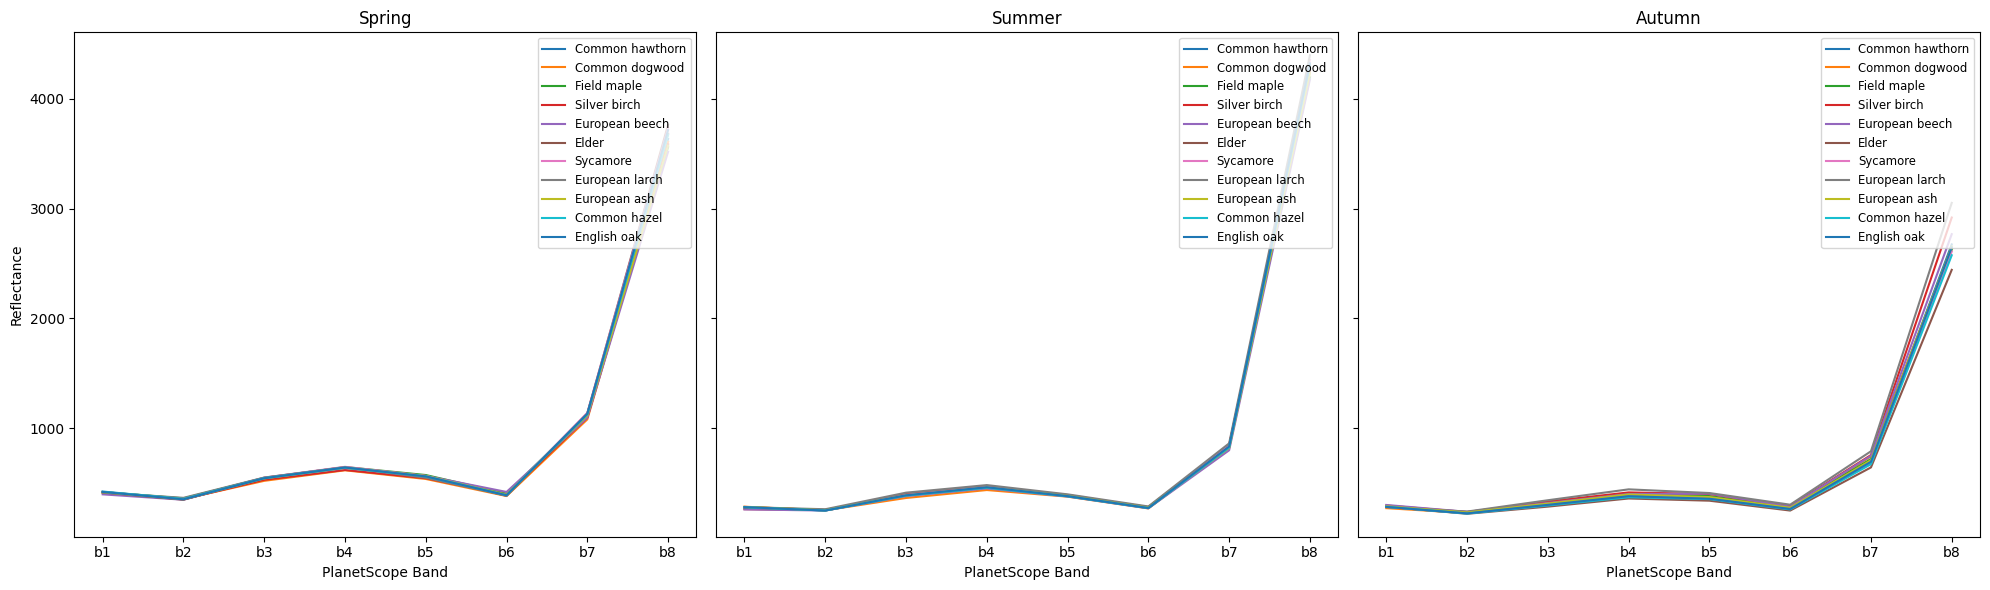

In [ ]:
# Get class labels from Spring as example
classes = results['Spring']['common_nam'].unique()

fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, (season, df) in enumerate(results.items()):
    ax = axs[i]

    for cls in classes:
        mean_vals = df[df['common_nam'] == cls][bands].mean()
        ax.plot(bands, mean_vals, label=cls)

    ax.set_title(season)
    ax.set_xlabel('PlanetScope Band')
    if i == 0:
        ax.set_ylabel('Reflectance')
    ax.legend(fontsize='small', loc='upper right')

plt.tight_layout()
plt.show()


In [ ]:
ndvi_results = {}

for month, path in images.items():
    image = ee.Image(path)
    ndvi = image.normalizedDifference(['b8', 'b5']).rename('NDVI')

    sampled = ndvi.sampleRegions(
        collection=filtered_tree_points,
        properties=['common_nam'],
        scale=3,
        geometries=False
    )

    features = sampled.getInfo()['features']
    df = pd.DataFrame([{**f['properties']} for f in features])

    if not df.empty:
        # Add month column for tracking
        df['month'] = month
        grouped = df.groupby('common_nam')['NDVI'].mean()
        ndvi_results[month] = grouped
    else:
        print(f"⚠️ No data sampled for {month}")


Well that is not very clear! Lets dive in the NDVIs.

In [ ]:
ndvi_df = pd.DataFrame(ndvi_results).transpose()
ndvi_df.index.name = 'Month'

# Sort using categorical month order
month_order = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
ndvi_df = ndvi_df.reindex(month_order)


In [ ]:
# Define PlanetScope monthly image paths and point data
planet_images = {
    'Apr': "projects/ee-kaplangorde/assets/wytham_ps/20220415_104236_95_2489_3B_AnalyticMS_SR_8b_clip",
    'May': "projects/ee-kaplangorde/assets/wytham_ps/20220519_104143_67_248f_3B_AnalyticMS_SR_8b_clip",
    'Jun': "projects/ee-kaplangorde/assets/wytham_ps/20220615_104134_65_248b_3B_AnalyticMS_SR_8b_clip",
    'Jul': "projects/ee-kaplangorde/assets/wytham_ps/20220716_104517_59_2479_3B_AnalyticMS_SR_8b_clip",
    'Aug': "projects/ee-kaplangorde/assets/wytham_ps/20220819_105313_71_2254_3B_AnalyticMS_SR_8b_clip",
    'Sep': "projects/ee-kaplangorde/assets/wytham_ps/20220916_104528_64_2478_3B_AnalyticMS_SR_8b_clip",
    'Oct': "projects/ee-kaplangorde/assets/wytham_ps/20221016_100915_77_2420_3B_AnalyticMS_SR_8b_clip",
    'Nov': "projects/ee-kaplangorde/assets/wytham_ps/20221123_105018_42_227a_3B_AnalyticMS_SR_8b_clip"
}

# Extract NDVI per species for each month
ndvi_results = {}

for month, path in planet_images.items():
    image = ee.Image(path)
    ndvi = image.normalizedDifference(['b8', 'b5']).rename('NDVI')  # PlanetScope: B8=NIR, B5=Red

    sampled = ndvi.sampleRegions(
        collection=filtered_tree_points,
        properties=['common_nam'],  # ⚠️ adjust if needed
        scale=3,
        geometries=False
    )

    features = sampled.getInfo()['features']
    if features:
        df = pd.DataFrame([{**f['properties']} for f in features])
        df['month'] = month
        grouped = df.groupby('common_nam')['NDVI'].mean()
        ndvi_results[month] = grouped
    else:
        print(f"⚠️ No data sampled for {month}")

# Convert to DataFrame
ndvi_df = pd.DataFrame(ndvi_results).transpose()
ndvi_df.index.name = 'Month'
ndvi_df = ndvi_df.reindex(['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov'])  # sort month order

# Preview
print(ndvi_df.head())

common_nam  Common hawthorn  Common hazel  English oak  European ash  \
Month                                                                  
Apr                0.559752      0.565264     0.566766      0.559326   
May                0.832590      0.835426     0.837561      0.828217   
Jun                0.841572      0.844202     0.843434      0.838843   
Jul                0.851642      0.852433     0.852365      0.849949   
Aug                0.813397      0.814177     0.815314      0.811124   

common_nam  Field maple  Sycamore  
Month                              
Apr            0.553564  0.568851  
May            0.824992  0.835565  
Jun            0.835376  0.843079  
Jul            0.844162  0.852037  
Aug            0.806130  0.814790  


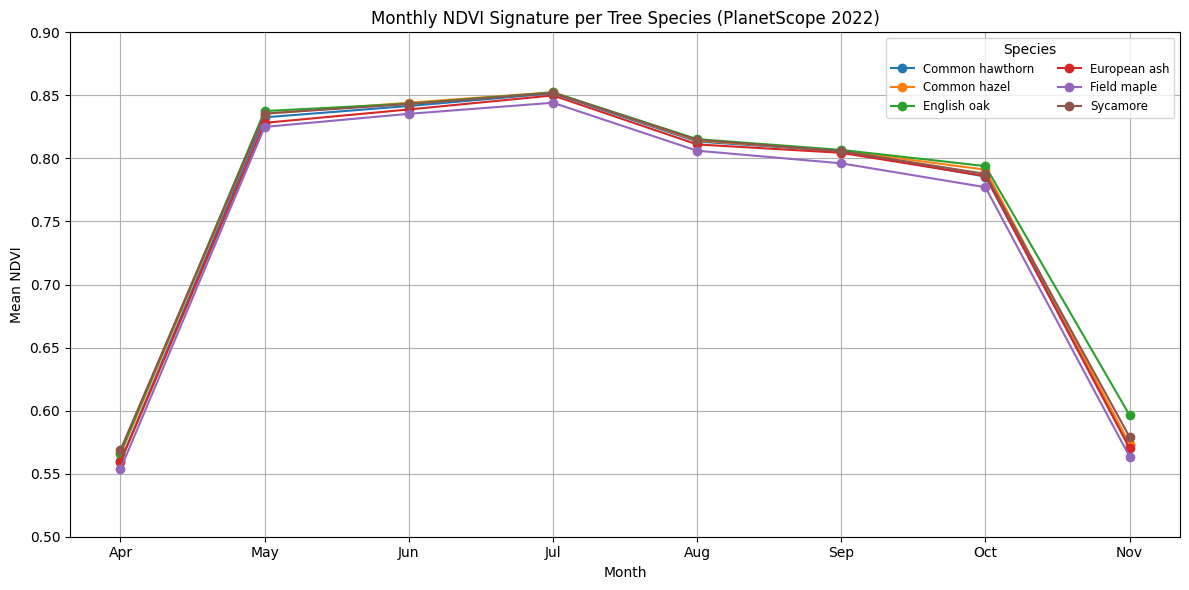

In [ ]:
plt.figure(figsize=(12, 6))
for col in ndvi_df.columns:
    plt.plot(ndvi_df.index, ndvi_df[col], marker='o', label=col)

plt.title('Monthly NDVI Signature per Tree Species (PlanetScope 2022)')
plt.xlabel('Month')
plt.ylabel('Mean NDVI')
plt.ylim(0.5, 0.9)
plt.grid(True)
plt.legend(title='Species', fontsize='small', ncol=2, loc='upper right')
plt.tight_layout()
plt.show()


In [ ]:
# Monthly PlanetScope assets and bands
planet_images = {
    '04': "projects/ee-kaplangorde/assets/wytham_ps/20220415_104236_95_2489_3B_AnalyticMS_SR_8b_clip",
    '05': "projects/ee-kaplangorde/assets/wytham_ps/20220519_104143_67_248f_3B_AnalyticMS_SR_8b_clip",
    '06': "projects/ee-kaplangorde/assets/wytham_ps/20220615_104134_65_248b_3B_AnalyticMS_SR_8b_clip",
    '07': "projects/ee-kaplangorde/assets/wytham_ps/20220716_104517_59_2479_3B_AnalyticMS_SR_8b_clip",
    '08': "projects/ee-kaplangorde/assets/wytham_ps/20220819_105313_71_2254_3B_AnalyticMS_SR_8b_clip",
    '09': "projects/ee-kaplangorde/assets/wytham_ps/20220916_104528_64_2478_3B_AnalyticMS_SR_8b_clip",
    '10': "projects/ee-kaplangorde/assets/wytham_ps/20221016_100915_77_2420_3B_AnalyticMS_SR_8b_clip",
    '11': "projects/ee-kaplangorde/assets/wytham_ps/20221123_105018_42_227a_3B_AnalyticMS_SR_8b_clip"
}
bands = ['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8']  # PlanetScope 8-band names

# Build stacked image (monthly bands + NDVI)
image_stack = None
for m, path in planet_images.items():
    img = ee.Image(path)
    renamed = img.select(bands).rename([f"{b}_{m}" for b in bands])
    ndvi = img.normalizedDifference(['b8', 'b5']).rename(f'NDVI_{m}')
    full = renamed.addBands(ndvi)
    image_stack = image_stack.addBands(full) if image_stack else full

# Buffer points for classification extent (10 m)
buffered_points = filtered_tree_points.map(lambda f: f.buffer(10))
buffered_area = buffered_points.geometry()

# Sample data at point locations
sampled = image_stack.sampleRegions(
    collection=filtered_tree_points,
    properties=['common_nam'],
    scale=3,
    geometries=False
)

# Map species names to numeric labels
unique_names = filtered_tree_points.aggregate_array('common_nam').distinct().getInfo()
class_map = {name: i for i, name in enumerate(unique_names)}
print("✅ Class map:", class_map)
ee_class_map = ee.Dictionary(class_map)

def set_label(feat):
    label = ee_class_map.get(feat.get('common_nam'))
    return feat.set('label', ee.Number(label))

training_data_labeled = sampled.map(set_label)

# 🎓 Train-test split
feature_list = [f"{b}_{m}" for m in planet_images.keys() for b in bands] + [f"NDVI_{m}" for m in planet_images.keys()]
training_data = training_data_labeled.randomColumn('random', seed=42)
train = training_data.filter(ee.Filter.lt('random', 0.8))
test = training_data.filter(ee.Filter.gte('random', 0.8))

# Train Random Forest classifier
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='label',
    inputProperties=feature_list
)

# Classify the image
classified_img = image_stack.classify(classifier).clip(buffered_area)

# Visualization
palette = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e',
           '#e6ab02', '#a6761d', '#666666', '#1f78b4', '#b2df8a']

Map = geemap.Map()
Map.centerObject(filtered_tree_points, zoom=17)
Map.addLayer(classified_img, {"min": 0, "max": len(class_map)-1, "palette": palette}, "Classified Trees")
Map.addLayer(filtered_tree_points, {}, "Tree Points")
Map


✅ Class map: {'Common hawthorn': 0, 'Field maple': 1, 'Sycamore': 2, 'European ash': 3, 'Common hazel': 4, 'English oak': 5}


Map(center=[51.776217398771294, -1.3372612108090889], controls=(WidgetControl(options=['position', 'transparen…

In [ ]:
#  Classify the test set
test_classified = test.classify(classifier)

# Error matrix (confusion matrix)
conf_matrix = test_classified.errorMatrix('label', 'classification')
print('Confusion Matrix:')
print(conf_matrix.getInfo())

# Overall Accuracy
accuracy = conf_matrix.accuracy()
print('Overall Accuracy:', accuracy.getInfo())

# Optional: Kappa statistic (useful for unbalanced classes)
kappa = conf_matrix.kappa()
#print('Kappa:', kappa.getInfo())


Confusion Matrix:
[[9, 1, 13, 1, 0, 0], [0, 4, 6, 5, 1, 0], [6, 2, 429, 25, 7, 5], [9, 2, 100, 77, 3, 0], [1, 2, 31, 5, 92, 0], [0, 0, 18, 2, 0, 0]]
Overall Accuracy: 0.7137850467289719
